# Continuous Time Quantum Walks

## Ring Topology

Once again, we introduce the position operator, and the evolution hamiltonian:

In [9]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = x

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def Shrodinger(t, state) : 
    dstate =-1j * Shift@state
    return dstate

In [26]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(Shrodinger, [0, endtime], state, t_eval=t_eval, method='RK45')

In [27]:
def Measure_pos(state):
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i] += abs(x)**2

    return positions

pos = Measure_pos(sol.y[:, -1])

Text(0.5, 1.0, 'Probability distribution at t=50')

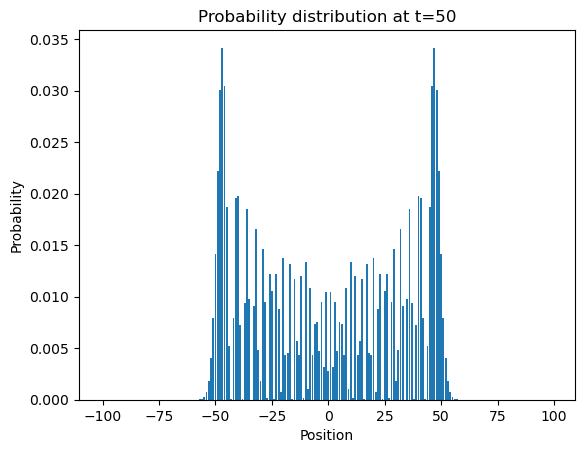

In [28]:
import matplotlib.pyplot as plt

plt.bar(np.arange(len(pos)) - ring_size//2, pos)

plt.xlabel("Position")
plt.ylabel("Probability")
plt.title('Probability distribution at t=50')

## Density Matrix

The reason is that we can more easily understand the dephasing, which means, the change from superposition to statistical mixture.

In [5]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex128)  # position vector
x[ring_size//2] = 1

state = x * np.transpose(x)

Tails = -1*np.eye(ring_size, k=-1, dtype=np.complex128)
Heads = -1*np.eye(ring_size, k=1, dtype=np.complex128)
Diag = 2*np.eye(ring_size, dtype=np.complex128)

a = np.zeros((ring_size, ring_size), dtype=np.complex128)
a[ring_size-1, 0] = -1

b = np.zeros((ring_size, ring_size), dtype=np.complex128)
b[0, ring_size-1] = -1

gamma = 0.5

Shift = gamma * (Tails + Heads + Diag + a + b) # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

def VNeumann(t, state) : 
    dstate =-1j * ( Shift * state - state * Shift)
    return dstate

In [6]:
from scipy.integrate import solve_ivp

endtime = 50
t_eval = np.arange(0, endtime, 0.1)
sol = solve_ivp(VNeumann, [0, endtime], state, t_eval=t_eval, method='RK45')

ValueError: could not broadcast input array from shape (200,200) into shape (200,)